In [1]:
run_batchprocess = False

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os,glob
import re
import sys
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/func')

from prepare_img_utils import *
from utils import get_paths

def get_record(s):
    return {
        'filename':s.get('filename'),
        'height': s.get('height'),
        'width': s.get('width'), 
        'ox': s.get('anchoring')[0], 
        'oy': s.get('anchoring')[1],
        'oz': s.get('anchoring')[2],
        'ux': s.get('anchoring')[3],
        'uy': s.get('anchoring')[4],
        'uz': s.get('anchoring')[5], 
        'vx': s.get('anchoring')[6], 
        'vy': s.get('anchoring')[7],
        'vz': s.get('anchoring')[8],
    }

HOMEDIR = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/'
paths = get_paths()
print(paths.keys())

dict_keys(['code_root', 'data_root', 'package_root'])


In [3]:
scaling_factor=1/32;
all_file_path = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/image_xml/*.jpg'
for f in glob.glob(all_file_path):
    print(os.path.basename(f).split('cell_img_')[1].split('.')[0])

MouseC_C2
MouseC_C3
MouseC_C4
MouseC_C5
MouseEg_Eg1
MouseEg_Eg2
MouseEg_Eg3
MouseEg_Eg5
MouseF_F1
MouseF_F2
MouseF_F3
MouseF_F4
MouseZM_ZM0
MouseZM_ZM1
MouseZM_ZM2
MouseZM_ZM3
MouseZM_ZM4
MouseZM_ZM5p1
MouseZM_ZM5p2
MouseZM_ZM6p1
MouseZM_ZM7p1
MouseZM_ZM7p2


In [4]:
slicename_all = [os.path.basename(f).split('cell_img_')[1].split('.')[0] for f in glob.glob(all_file_path)]
slicename_all.sort()
print(slicename_all, len(slicename_all))

['MouseC_C2', 'MouseC_C3', 'MouseC_C4', 'MouseC_C5', 'MouseEg_Eg1', 'MouseEg_Eg2', 'MouseEg_Eg3', 'MouseEg_Eg5', 'MouseF_F1', 'MouseF_F2', 'MouseF_F3', 'MouseF_F4', 'MouseZM_ZM0', 'MouseZM_ZM1', 'MouseZM_ZM2', 'MouseZM_ZM3', 'MouseZM_ZM4', 'MouseZM_ZM5p1', 'MouseZM_ZM5p2', 'MouseZM_ZM6p1', 'MouseZM_ZM7p1', 'MouseZM_ZM7p2'] 22


# batch process

In [5]:
if run_batchprocess:
    import plotly.express as px
    import cv2
    from registerCCF_util import *

    save_flag = True
    plotting_2d = False
    plotting_3d = False
    slicenum = ['1']
    slicenum=[int(i) for i in slicenum]

    for name_of_slice in slicename_all:
        image_files=glob.glob(HOMEDIR + f'/processing/image_xml/*{name_of_slice}.jpg')
        # load your file
        flat_name=[]  
        for i in image_files:
            result=re.search('(.*).jpg', i)
            n=result.group(1)+('_nl.flat')
            flat_name+=[n]
        assert(len(image_files)==1)
        im = cv2.imread(image_files[0])
        h,w=im.shape[:2]
        json_name=image_files 
        d = {'slicenum': slicenum, 'json_name': json_name,'flat_name':flat_name}
        name_df=pd.DataFrame(data=d)
        neurons=pd.read_csv(HOMEDIR+f'/processing/filt_neurons_all/filt_neurons_{name_of_slice}.csv')
        neurons=neurons[neurons['slice'].isin(slicenum)]
        Max=neurons['x'].max()
        Min=neurons['y'].max()
        neurons['rescale_x']=neurons['x']*scaling_factor
        neurons['rescale_y']=neurons['y']*scaling_factor
        neurons['rescale_x'] = neurons['rescale_x'].astype(float)+500 # this was accounting for the padding that we created for the image
        neurons['rescale_y'] = neurons['rescale_y'].astype(float)+500

        # load visualign results 
        with open(HOMEDIR+f'/processing/visualign_rez/{name_of_slice}.json') as f:
            vafile=json.load(f)
        details={s.get('filename'):s for s in vafile['slices']}
        assert(name_of_slice in list(details.keys())[0])

        rez = neurons.groupby('slice', group_keys=False).apply(lambda g: get_adjusted_points(g.assign(slice=g.name), name_df,details)).reset_index(drop=True)
        neurons[['adjusted_x', 'adjusted_y']]= rez
        neurons_nl=neurons.copy()
        neurons_nl['clustid'] =neurons_nl['clustid'].astype(str)

        # load quickniii results 
        f = open(HOMEDIR+f'/processing/quicknii_rez/quicknii_{name_of_slice}.json','r')
        data=json.loads(f.read())
        anchor=pd.DataFrame.from_records([get_record(s) for s in data['slices']])
        f.close()

        vox_dfs = []
        for slice_num, df in neurons_nl.groupby('slice'):
            quicknii_cord = get_quicknii_cord(slice_num, df,name_df,anchor,h,w) # Height and Width of image file
            vox_cord = get_vox_cord(quicknii_cord)
            vox_dfs += [vox_cord]    
        vox_df = pd.concat(vox_dfs)

        if save_flag:
            vox_df.to_csv(HOMEDIR+f'/processing/registered_foo/registered_{name_of_slice}.csv',index=False)

        # optional plotting!
        if plotting_3d:
            plot_df = vox_df.copy()
            fig = px.scatter_3d(plot_df, x='y_CCF', y='z_CCF', z='x_CCF', color='clustid')
            fig.update_traces(marker=dict(size=.5),selector=dict(mode='markers'))
            fig.update_scenes(aspectmode='data')
            fig.show()
        elif plotting_2d:
            fig = px.scatter(plot_df, x='z_CCF', y='y_CCF', color='clustid')
            fig.update_traces(marker=dict(size=1),selector=dict(mode='markers'))
            fig.update_yaxes(scaleanchor='x', scaleratio=1)
            fig.show()
else:
    print('skip the batch process!')

skip the batch process!


# plot some results for testing purpose

#  now pull all these together 

In [6]:
from pprint import pprint 

In [7]:
reg_file_path = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/registered/'
pprint(glob.glob(reg_file_path+'*'))

['/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/registered/registered_MouseC_C2.csv',
 '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/registered/registered_MouseC_C3.csv',
 '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/registered/registered_MouseC_C4.csv',
 '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/registered/registered_MouseC_C5.csv',
 '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/registered/registered_MouseEg_B3.csv',
 '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/registered/registered_MouseEg_Eg1.csv',
 '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/registered/registered_MouseEg_Eg2.csv',
 '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/registered/registered_MouseEg_Eg3.csv',
 '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/registered/registered_MouseEg_Eg

In [8]:
paths

{'code_root': '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/',
 'data_root': '/allen/aind/scratch/shuonan.chen/pons_images/',
 'package_root': PosixPath('/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing')}

# load all the coords + genes

In [9]:

genecounts_all = dict()
reg_points_all = dict()
for name in slicename_all:  
    
    reg_points_path = reg_file_path + f'registered_{name}.csv'
    df = pd.read_csv(reg_points_path, on_bad_lines='skip')[['neuron_id','x_CCF','y_CCF','z_CCF']]    
    reg_points_all[name] = df
    
    thisdircheck = (paths['data_root'] + name + '/' + 'analyzed_data/*/region_*/')    
    alltifregions = np.array([[s for s in m.split('/') if 'region' in s][0] for m in glob.glob(thisdircheck + '/images/*.tif')])
    values, counts = np.unique(alltifregions, return_counts=True)
    region_chosen = values[np.argmax(counts)]
    thisdircheck = (paths['data_root'] + name + '/' + f'analyzed_data/*/{region_chosen}/')

    cell_loc_path = glob.glob(thisdircheck + 'cell_metadata.csv')[0]
    countmatrix_path = glob.glob(thisdircheck+'cell_by_gene.csv')[0]
    count_mtx = pd.read_csv(countmatrix_path, index_col=0).sort_index()
    genecounts_all[name] = count_mtx

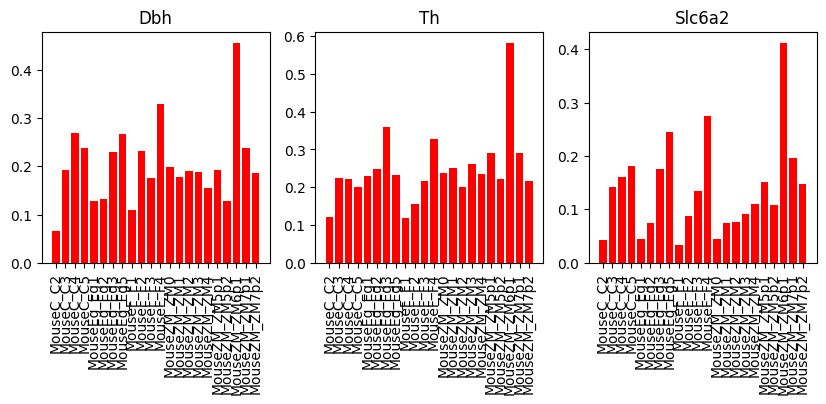

In [10]:
markergenes = ['Dbh', 'Th', 'Slc6a2']
plt.figure(figsize = (10, 3))
for k,g in enumerate(markergenes):
    plt.subplot(1,3,k+1)
    for k, v in genecounts_all.items():
        expr = np.array(v[g]).flatten()
        plt.bar(k,np.mean(expr), color = 'red')
    plt.xticks(rotation=90);
    plt.title(g)
    


In [11]:
out_df_gene = []
out_df_loc = []
for p,name in enumerate(slicename_all):
    totalexpression = np.prod(np.array([genecounts_all[name][k].values for k in markergenes]), 0)
     # Boolean to indicaet if all three marker genes have to be expressed  in this cell!
    keptcellID = totalexpression>10   # if this is zero, we will have 7k cells. if this is 10 then we will have 5.4k cells
    
    # for gene counts
    foo_df = genecounts_all[name].iloc[keptcellID] 
    foo_df= foo_df.assign(slicename=list(np.repeat(name,(keptcellID).sum())))
    out_df_gene.append(foo_df)
    
    # for locations
    foo_df = reg_points_all[name].iloc[keptcellID]
    foo_df.index = foo_df['neuron_id']
    out_df_loc.append(foo_df)
    
out_df_gene = pd.concat(out_df_gene)    
out_df_loc = pd.concat(out_df_loc)    
out_df_gene.index.name = 'neuron_id'

In [12]:
df = pd.concat((out_df_loc,out_df_gene),axis=1)

In [13]:
import anndata as ad
ccf_columns = [col for col in df.columns if "CCF" in col]  # CCF columns
obs_columns = ["neuron_id", "slicename"] + ccf_columns  # Include slicename in obs

columns_to_exclude = [col for col in df.columns if "Blank" in col] + ccf_columns + ["slicename"]

df_filtered = df.drop(columns=columns_to_exclude)
df_filtered.set_index("neuron_id", inplace=True)

adata_mer = ad.AnnData(df_filtered)
adata_mer.obs = df[obs_columns].set_index("neuron_id")


In [14]:

allmousenames = ['MouseC','MouseF','MouseEg','MouseZM']
section_identifier_highlevel = [next(mouse for mouse in allmousenames if mouse in name)
                                for name in adata_mer.obs.slicename]    

In [15]:
dictkeys = list(['MouseC', 'MouseEg', 'MouseF', 'MouseZM'])
dictvals = list(['M', 'F', 'F', 'M'])
mouse_sex_map = {key: value for key, value in zip(dictkeys, dictvals)}

adata_mer.obsm["spatial"] = adata_mer.obs[['x_CCF','y_CCF','z_CCF']].values
adata_mer.raw = adata_mer.copy()
adata_mer.obs['mouse_name'] = section_identifier_highlevel
adata_mer.obs["slicename"] = adata_mer.obs["slicename"].astype("category")
adata_mer.obs['mouse_sex'] = adata_mer.obs['mouse_name'].map(mouse_sex_map)

In [16]:
markergenesid = np.array([np.where(adata_mer.var_names==m)[0][0] for m in markergenes])
totalexpression = np.prod(adata_mer.X[:,markergenesid], 1)
keptcellID = totalexpression>0  # Boolean to indicaet if all three marker genes have to be expre
adata_mer = adata_mer[keptcellID]

In [17]:
totalexpression.shape

(4975,)

# scvi

In [18]:
import scvi

In [24]:
scvi.settings.seed = 1
umap_random_state = 307
adata_mer = adata_mer.copy()
scvi.model.SCVI.setup_anndata(adata_mer, batch_key="slicename")
model = scvi.model.SCVI(adata_mer, n_hidden=128, n_layers=2, n_latent=10)
model.train(max_epochs=200)


INFO: [rank: 0] Seed set to 1
INFO:lightning.fabric.utilities.seed:[rank: 0] Seed set to 1
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /allen/aind/scratch/shuonan.chen/conda_envs/torch_on ...
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` comma

Training:   0%|          | 0/200 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=200` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


In [71]:
sc.pp.neighbors??

In [74]:
adata_mer.obsm["X_scVI"] = model.get_latent_representation()
sc.pp.neighbors(adata_mer, use_rep="X_scVI",  random_state=umap_random_state, n_neighbors=30)
sc.tl.umap(adata_mer, random_state=210)
sc.tl.leiden(adata_mer, resolution=0.5,  random_state=umap_random_state)


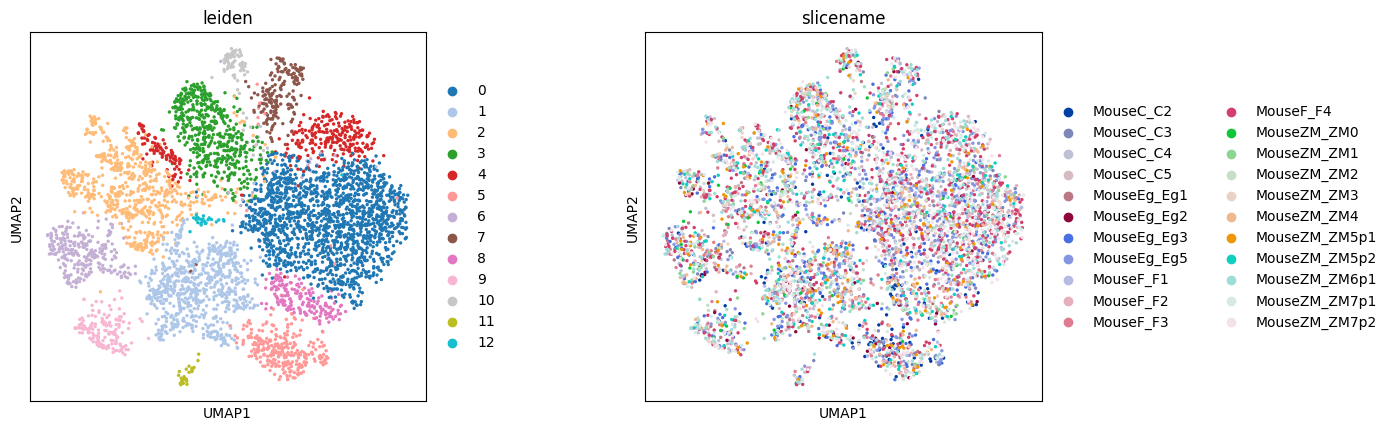

In [75]:
ax = sc.pl.umap(
    adata_mer,
    color=["leiden",'slicename'],show = False,
    ncols=3,
)
for a in ax:
    a.set_aspect('equal')

# get batch corrected reults

In [76]:
import anndata

In [77]:
adata_BN = model.get_normalized_expression(adata_mer, return_numpy=False)#, library_size = 10000)
adata_BN = anndata.AnnData(adata_BN)
adata_BN.obs = adata_mer.obs.copy()
adata_BN.obsm = adata_mer.obsm.copy()




# here we must choose our clusters

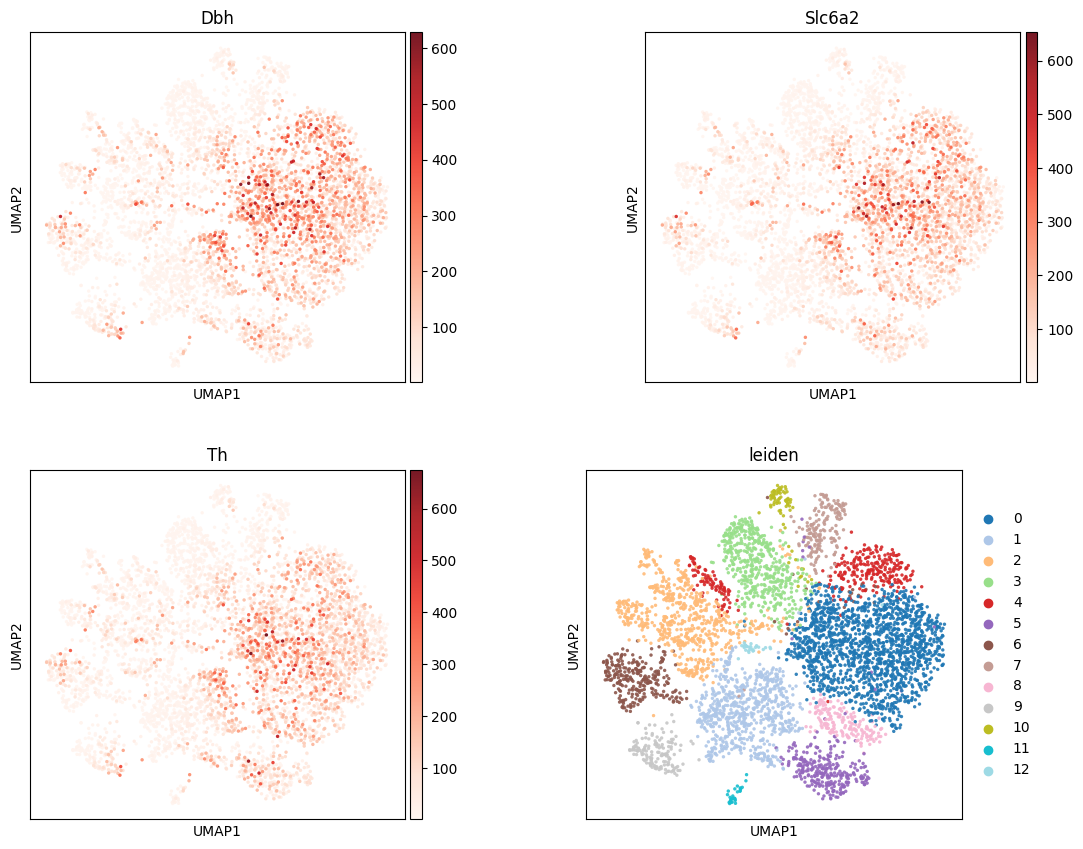

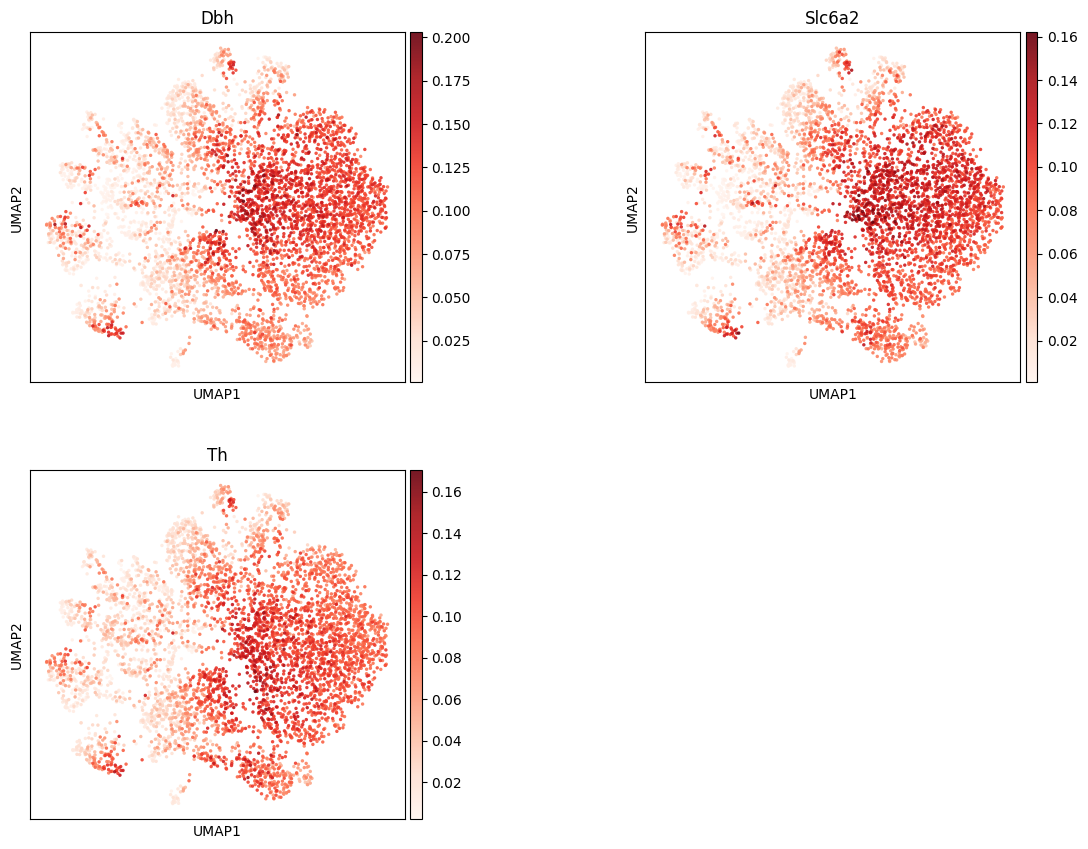

In [78]:
axes = sc.pl.umap(adata_mer, color=['Dbh','Slc6a2','Th','leiden'],
           cmap ='Reds',ncols=2,palette="tab20",show = False,
           alpha =.9) 
for a in axes:
    a.set_aspect('equal')
    
axes = sc.pl.umap(adata_BN, color=['Dbh','Slc6a2','Th'],
           cmap ='Reds',ncols=2,palette="tab20",show = False,
           alpha =.9) 
for a in axes:
    a.set_aspect('equal')    

In [29]:
adata_mer.obsm['X_umap'].shape

(4975, 2)

In [34]:
np.sum(adata_mer[:,['Dbh','Slc6a2','Th']].X, 1).shape

(4975,)

Text(0.5, 1.0, 'sum of marker genes')

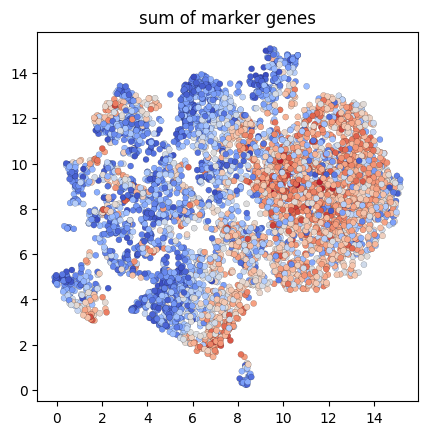

In [43]:
plt.scatter(adata_mer.obsm['X_umap'][:,0],adata_mer.obsm['X_umap'][:,1], 
            c = np.log1p(np.sum(adata_mer[:,['Dbh','Slc6a2','Th']].X, 1)), 
            s= 19, cmap = 'coolwarm', edgecolor = 'k', linewidth = .1
           )
plt.gca().set_aspect('equal')
plt.title('sum of marker genes')

Text(0.5, 1.0, 'MAX of marker genes')

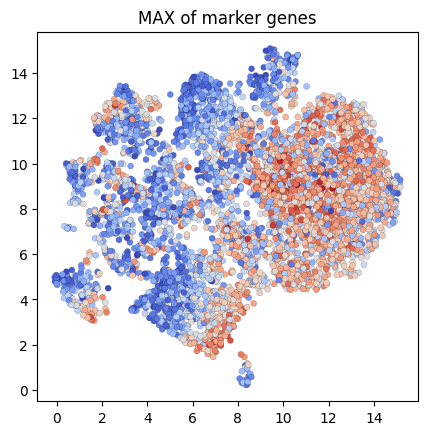

In [44]:
plt.scatter(adata_mer.obsm['X_umap'][:,0],adata_mer.obsm['X_umap'][:,1], 
            c = np.log1p(np.max(adata_mer[:,['Dbh','Slc6a2','Th']].X, 1)), 
            s= 19, cmap = 'coolwarm', edgecolor = 'k', linewidth = .1
           )
plt.gca().set_aspect('equal')
plt.title('MAX of marker genes')

Text(0.5, 1.0, 'DV axis')

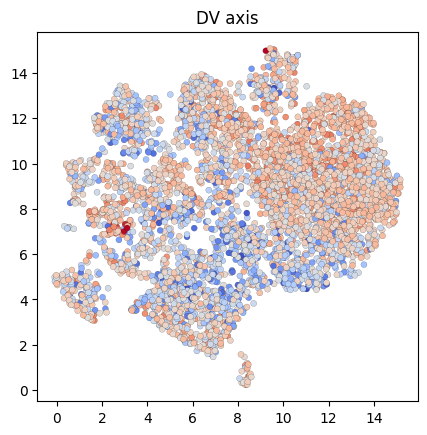

In [46]:
plt.scatter(adata_mer.obsm['X_umap'][:,0],adata_mer.obsm['X_umap'][:,1], 
            c = adata_mer.obsm['spatial'][:,0], 
            s= 19, cmap = 'coolwarm', edgecolor = 'k', linewidth = .1)
plt.gca().set_aspect('equal')
plt.title('DV axis')

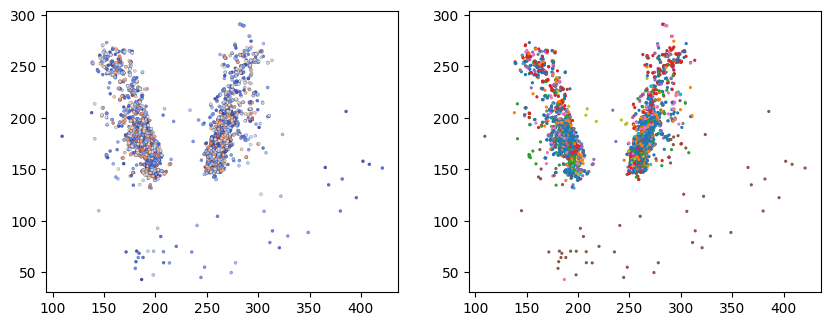

In [67]:
s = 5
plt.figure(figsize = (10, 4))
plt.subplot(1,2,1)
plt.scatter(adata_mer.obsm['spatial'][:,2],adata_mer.obsm['spatial'][:,1], 
            c = np.log1p(np.sum(adata_mer[:,['Dbh','Slc6a2','Th']].X, 1)), 
            s= s, cmap = 'coolwarm', edgecolor = 'k', linewidth = .1
           )
plt.gca().set_aspect('equal')

plt.subplot(1,2,2)
plt.scatter(adata_mer.obsm['spatial'][:,2],adata_mer.obsm['spatial'][:,1], 
            c=adata_mer.obs['leiden'].astype("category").cat.codes,
            cmap = 'tab10',
            s= s/3 #, edgecolor = 'k', linewidth = .1
           )
plt.gca().set_aspect('equal')